<a href="https://colab.research.google.com/github/clin0603/csci3052u-group-project/blob/main/milestone2_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%pip install numpy pandas matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [2]:
#imports

import os
import numpy as np
import pandas as pd


import matplotlib.pyplot as plt
import seaborn as seaborn_sns

## Research Question

## Data Source and License

In [3]:
#TEMPLATE
# 1. Data Source & License declaration
DATA_SOURCE = "Consumer Fiancial Protection Bureau - HMDA Historial Data"
DATA_URL = "https://www.consumerfinance.gov/data-research/hmda/historic-data/?geo=nationwide&records=all-records&field_descriptions=labels"
LICENSE = "Publicly available"

YEARS = [2007, 2008, 2009]
GEOGRAPHY = "Nevada"
RECORDS = "All records"

## Data Card

In [4]:
#TEMPLATE
file_paths = [
    "Cut_Mortage_Data07.csv",
    "Cut_Mortage_Data08.csv",
    "Cut_Mortage_Data09.csv"
]

if all(os.path.exists(file) for file in file_paths):
    # Load and combine the datasets
    df = pd.concat(
        [pd.read_csv(file, low_memory=False) for file in file_paths],
        ignore_index=True
    )
    print("=== DATA CARD ===")
    print(f"Source: {DATA_SOURCE}")
    print(f"License: {LICENSE}")
    print(f"Total Rows (Observations): {df.shape[0]:,}")
    print(f"Total Columns (Features): {df.shape[1]}")
else:
    print("Warning: One or more files not found. Please check your file paths.")

=== DATA CARD ===
Source: Consumer Fiancial Protection Bureau - HMDA Historial Data
License: Publicly available
Total Rows (Observations): 101,864
Total Columns (Features): 78


## Sample Inputs and Outputs

In [5]:
#template

sample_features = ['as_of_year', 'loan_amount_000s', 'applicant_income_000s', 'loan_type', 'loan_purpose'] 
target_column = 'approved'

if set(sample_features).issubset(df.columns) and 'action_taken' in df.columns:
     # Keep only approved and denied applications
    df_model = df[df['action_taken'].isin([1, 2, 3])].copy()

    # Create binary target: 1 = Approved, 0 = Denied
    df_model[target_column] = df_model['action_taken'].isin([1, 2]).astype(int)

    # Select 2 approved and 2 denied applications
    sample = pd.concat([
        df_model[df_model[target_column] == 1].head(2),
        df_model[df_model[target_column] == 0].head(2)
    ])

    print("=== SAMPLE INPUTS (X) & OUTPUTS (y) ===")

    print("\nSample Input Rows (Features - X):")
    print(sample[sample_features])

    print("\nSample Outputs (Target - y):")
    print(sample[target_column])

else:
    print("Note: Check your sample features and target column.")
    display(df.head(3))

# Separate input features and target
X = df_model[sample_features]
y = df_model[target_column]

print("Input shape (X):", X.shape)
print("Output shape (y):", y.shape)

# Check the possible target values
print("Target values:", y.unique())

# Count approved and denied applications
print("\nTarget distribution:")
print(y.value_counts())



=== SAMPLE INPUTS (X) & OUTPUTS (y) ===

Sample Input Rows (Features - X):
    as_of_year  loan_amount_000s  applicant_income_000s  loan_type  \
0         2007                41                   84.0          1   
1         2007               295                  119.0          3   
7         2007               225                   53.0          1   
15        2007               285                   75.0          1   

    loan_purpose  
0              1  
1              3  
7              3  
15             1  

Sample Outputs (Target - y):
0     1
1     1
7     0
15    0
Name: approved, dtype: int64
Input shape (X): (74103, 5)
Output shape (y): (74103,)
Target values: [1 0]

Target distribution:
approved
1    54767
0    19336
Name: count, dtype: int64


The code above shows sample inputs and outputs from the mortgage datasets to help us understand what information will be used to predict loan approval. This sample only displays applications from 2007, the full dataset includes 2007, 2008, and 2009. The inputs include loan amount, applicant income, loan type, loan purpose, and year. The output shows whether each application was approved (1) or denied (0). After filtering the data, we have a total of 74,103 mortgage applications with 5 input features. Out of these applications, 54,767 (73.9%) were approved, while 19,336 (26.1%) were denied. This shows that our dataset is imbalanced, since there are significantly more approved applications than denied ones.

## Target and ML Task

We use **1 for approved** and **0 for denied**. Loans that were approved or given out are counted as approved, while rejected applications are counted as denied. Other outcomes, such as withdrawn or incomplete applications, are not included.

To make these predictions, we look at information such as the year, loan amount, applicant income, loan type, and loan purpose. By comparing data from **2007, 2008, and 2009**, we want to see how mortgage approvals and denials changed around the 2008 Financial Crisis and how accurately our model can predict these decisions.

## Initial EDA

=== DATASET STRUCTURE AND DIMENSIONS ===
This shows the number of rows, columns, data types, and memory usage.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101864 entries, 0 to 101863
Data columns (total 78 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   as_of_year                      101864 non-null  int64  
 1   respondent_id                   101864 non-null  object 
 2   agency_name                     101864 non-null  object 
 3   agency_abbr                     101864 non-null  object 
 4   agency_code                     101864 non-null  int64  
 5   loan_type_name                  101864 non-null  object 
 6   loan_type                       101864 non-null  int64  
 7   property_type_name              101864 non-null  object 
 8   property_type                   101864 non-null  int64  
 9   loan_purpose_name               101864 non-null  object 
 10  loan_purpose                 

,as_of_year,respondent_id,agency_name,agency_abbr,agency_code,loan_type_name,loan_type,property_type_name,property_type,loan_purpose_name,...,edit_status_name,edit_status,sequence_number,population,minority_population,hud_median_family_income,tract_to_msamd_income,number_of_owner_occupied_units,number_of_1_to_4_family_units,application_date_indicator
0,2007,8,Office of the Comptroller of the Currency,OCC,1,Conventional,1,One-to-four family dwelling (other than manufa...,1,Home purchase,...,Quality edit failure only,6.0,467047,4145.0,33.389999,60100.0,141.750000,1293.0,1734.0,0
1,2007,13044,Office of the Comptroller of the Currency,OCC,1,VA-guaranteed,3,One-to-four family dwelling (other than manufa...,1,Refinancing,...,NaN,NaN,657773,4401.0,22.930000,60100.0,132.929993,1222.0,1500.0,0
2,2007,18039,Office of Thrift Supervision,OTS,4,Conventional,1,One-to-four family dwelling (other than manufa...,1,Home purchase,...,NaN,NaN,1017842,8289.0,16.290001,64000.0,104.129997,2433.0,2870.0,2
3,2007,1644643,Federal Reserve System,FRS,2,Conventional,1,One-to-four family dwelling (other than manufa...,1,Home purchase,...,NaN,NaN,1017740,1337.0,17.350000,60100.0,175.449997,464.0,540.0,2
4,2007,8,Office of the Comptroller of the Currency,OCC,1,FSA/RHS-guaranteed,4,One-to-four family dwelling (other than manufa...,1,Home purchase,...,NaN,NaN,48406,2381.0,11.470000,58400.0,117.150002,675.0,998.0,0



Last 5 rows:


,as_of_year,respondent_id,agency_name,agency_abbr,agency_code,loan_type_name,loan_type,property_type_name,property_type,loan_purpose_name,...,edit_status_name,edit_status,sequence_number,population,minority_population,hud_median_family_income,tract_to_msamd_income,number_of_owner_occupied_units,number_of_1_to_4_family_units,application_date_indicator
101859,2009,8,Office of the Comptroller of the Currency,OCC,1,FSA/RHS-guaranteed,4,One-to-four family dwelling (other than manufa...,1,Home purchase,...,NaN,NaN,57113,8487.0,22.959999,63800.0,80.830002,1680.0,3287.0,2
101860,2009,18039,Office of Thrift Supervision,OTS,4,FHA-insured,2,One-to-four family dwelling (other than manufa...,1,Home purchase,...,Quality edit failure only,6.0,257322,6663.0,30.570000,65400.0,102.500000,1145.0,1479.0,0
101861,2009,8,Office of the Comptroller of the Currency,OCC,1,FHA-insured,2,One-to-four family dwelling (other than manufa...,1,Refinancing,...,NaN,NaN,477283,3877.0,25.480000,65400.0,135.600006,1296.0,1661.0,0
101862,2009,24,Office of the Comptroller of the Currency,OCC,1,FHA-insured,2,Manufactured housing,2,Refinancing,...,Quality edit failure only,6.0,188393,7276.0,22.090000,65400.0,144.839996,2166.0,2498.0,0
101863,2009,8,Office of the Comptroller of the Currency,OCC,1,VA-guaranteed,3,One-to-four family dwelling (other than manufa...,1,Refinancing,...,NaN,NaN,475511,4471.0,39.540001,65400.0,119.099998,1344.0,1496.0,2



5 random rows:


...


=== APPROVALS AND DENIALS BY YEAR ===
This compares the number of approved and denied applications from 2007 to 2009.


approved,Denied,Approved
as_of_year,,
2007,7953,21564
2008,8095,21341
2009,3288,11862



=== APPROVAL AND DENIAL PERCENTAGES BY YEAR ===
This shows the percentage of approved and denied applications each year.


approved,Denied,Approved
as_of_year,,
2007,26.94,73.06
2008,27.50,72.50
2009,21.70,78.30



=== APPROVAL AND DENIAL GRAPH ===


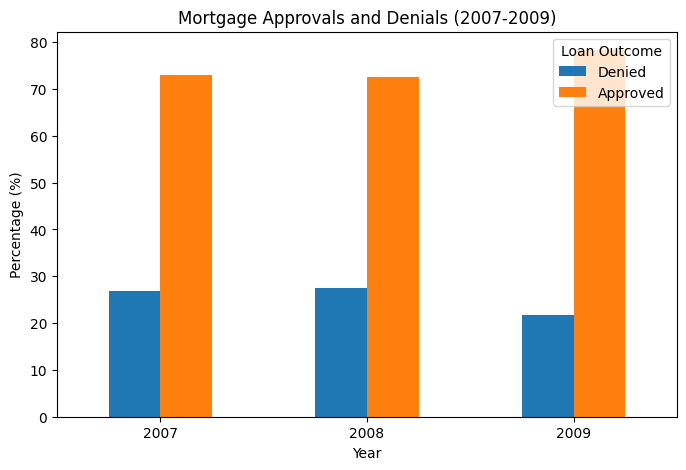

=== LOAN AMOUNT AND INCOME BY YEAR ===
This compares the median loan amounts and applicant incomes for each year (in thousands of dollars).


,loan_amount_000s,applicant_income_000s
as_of_year,,
2007,200.0,75.0
2008,192.0,72.0
2009,164.0,67.0


In [6]:
#TEMPLATE
# 1. Inspect the structure and dimensions
print("=== DATASET STRUCTURE AND DIMENSIONS ===")
print("This shows the number of rows, columns, data types, and memory usage.")


df.info()  # Rows, columns, memory usage, and data types
print("\nDataset shape (rows, columns):", df.shape)  # (number of rows, number of columns)

# 2. Preview the rows
print("\n=== DATASET PREVIEW ===")
print("This shows examples of mortgage records in our dataset.")


print("\nFirst 5 rows:")  # View first 5 rows
display(df.head())

print("\nLast 5 rows:")  # View last 5 rows
display(df.tail())

print("\n5 random rows:") # View 5 random rows
display(df.sample(5))


# 3. Check data quality
print("\n=== DATA QUALITY ===")
print("This checks for missing values and identical rows in the dataset.")

print("\nMissing values per column:") 
display(df.isnull().sum()) # Total missing (NaN) values per column

print("\nNumber of duplicate rows:")
print(df.duplicated().sum()) # Total identical duplicate rows

# 4. Statistical summaries
print("\n=== STATISTICAL SUMMARIES ===")
print("This summarizes the numerical and categorical columns.")

print("\nNumerical columns:")
display(df.describe())  # Summary statistics for numerical columns
print("\nCategorical columns:")
display(df.describe(include="object"))  # Summary statistics for text/categorical columns

# 5. Column-specific checks
print("\n=== LOAN APPLICATION OUTCOMES ===")
print("This shows how many applications have each outcome.")

print("\nNumber of records for each outcome:") # Frequency count of unique values
display(df["action_taken"].value_counts())

print("\nNumber of unique outcomes:")
print(df["action_taken"].nunique()) # Number of unique values


# 6. Missing values in selected features
print("=== MISSING VALUES IN SELECTED FEATURES ===")

missing_values = df_model[sample_features].isnull().sum()
missing_percent = df_model[sample_features].isnull().mean() * 100

print("\nMissing values:")
display(missing_values)


print("\nMissing percentages:")
display(missing_percent.round(2))

# 7 Compare approved and denied applications by year
print("\n=== APPROVALS AND DENIALS BY YEAR ===")
print("This compares the number of approved and denied applications from 2007 to 2009.")

year_counts = pd.crosstab(
    df_model["as_of_year"],
    df_model["approved"]
)

year_counts = year_counts.rename(
    columns={0: "Denied", 1: "Approved"}
)
display(year_counts)


# Calculate percentages within each year
print("\n=== APPROVAL AND DENIAL PERCENTAGES BY YEAR ===")
print("This shows the percentage of approved and denied applications each year.")

year_percent = year_counts.div(
    year_counts.sum(axis=1), axis=0
) * 100

display(year_percent.round(2))

# 8. Visualize approvals and denials by year
print("\n=== APPROVAL AND DENIAL GRAPH ===")

year_percent.plot(kind="bar", figsize=(8, 5))

plt.title("Mortgage Approvals and Denials (2007-2009)")
plt.xlabel("Year")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.legend(title="Loan Outcome")
plt.show()


# 9. Compare loan amounts and income by year
print("=== LOAN AMOUNT AND INCOME BY YEAR ===")
print("This compares the median loan amounts and applicant incomes for each year (in thousands of dollars).")


display(
    df_model.groupby("as_of_year")[
        ["loan_amount_000s", "applicant_income_000s"]
    ].median()
)

Our EDA compares mortgage approvals and denials in Nevada from 2007 to 2009. Looking at the results, the approval and denial rates stayed relatively similar across the three years, with most applications being approved. The approval rate slightly decreased from 73.06% in 2007 to 72.50% in 2008, before increasing to 78.30% in 2009. Although the approval rates did not change drastically, both median loan amounts and applicant incomes decreased over time. We also found that 4.65% of applications have missing income values. Since we are using smaller cut datasets, these results may not fully represent Nevada's overall mortgage approval patterns.

## Risks and Limitations

Historical Data Quality:
Algorithm Explanation:
Data Leakage in Temporal (Time-Series) Data: (basically if we use future data to measure past data)

## Train/Validation/Test Strategy

In [ ]:

time_col = "as_of_year"

print("=== TRAIN / VALIDATION / TEST STRATEGY ===")
train_df = df_model[df_model[time_col] == 2007].copy()
val_df = df_model[df_model[time_col] == 2008].copy()
test_df = df_model[df_model[time_col] == 2009].copy()

print(f"Training Set (2007):    {len(train_df):,} rows")
print(f"Validation Set (2008): {len(val_df):,} rows")
print(f"Test Set (2009):       {len(test_df):,} rows")

X_train = train_df[sample_features]
y_train = train_df[target_column]

X_val = val_df[sample_features]
y_val = val_df[target_column]

X_test = test_df[sample_features]
y_test = test_df[target_column]

print("\n=== FEATURE / TARGET SHAPES ===")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

=== TRAIN / VALIDATION / TEST SPLIT ===
Training set:    29517 rows (2007)
Validation set: 29436 rows (2008)
Test set:        15150 rows (2009)

Training years: [np.int64(2007)]
Validation years: [np.int64(2008)]
Test years: [np.int64(2009)]


## Primary Evaluation Metric

In [ ]:

time_col = "as_of_year"

print("=== TRAIN / VALIDATION / TEST STRATEGY ===")
train_df = df_model[df_model[time_col] == 2007].copy()
val_df = df_model[df_model[time_col] == 2008].copy()
test_df = df_model[df_model[time_col] == 2009].copy()

print(f"Training Set (2007):    {len(train_df):,} rows")
print(f"Validation Set (2008): {len(val_df):,} rows")
print(f"Test Set (2009):       {len(test_df):,} rows")

X_train = train_df[sample_features]
y_train = train_df[target_column]

X_val = val_df[sample_features]
y_val = val_df[target_column]

X_test = test_df[sample_features]
y_test = test_df[target_column]

print("\n=== FEATURE / TARGET SHAPES ===")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

ModuleNotFoundError: No module named 'sklearn'

## Feasibility and Compute Plan